<div align="center">

# <span style="color:#2C3E50;">Urban Flood Mapping Using Satellite SAR Data</span>
## <span style="color:#34495E;">Cross-Modal Hybrid CNN-Mamba Networks (CM-UNet Adaptation)</span>

</div>

This notebook implements **Approach 2: CM-UNet** — a hybrid architecture that combines convolutional neural networks with Mamba-based Selective State Space Models (SSMs) to address the fundamental trade-off in SAR flood segmentation:

- **CNN Encoder**: Dense multi-convolution blocks aggressively suppress high-frequency multiplicative speckle noise and extract highly localized textural features (e.g., double-bounce lines from flooded building façades).
- **Mamba Bottleneck**: Deep SSM blocks situated at the bottleneck selectively recurse over the spatial sequence to establish long-range dependencies across the 20-meter resolution grid, avoiding catastrophic edge loss from pure global models.
- **CNN Decoder**: Skip-connected decoder stages precisely reconstruct flood boundaries by fusing local encoder features with the globally-aware bottleneck representations.

The three target classes are:
- **Non-Flooded** (background)
- **Flooded Open** (flood water in open areas)
- **Flooded Urban** (flood water in urban zones)

<div align="center">

## <span style="color:#16A085;">Project Information</span>

</div>

| **Field**          | **Details**                                    |
|--------------------|------------------------------------------------|
| **Course**         | Deep Learning Project                          |
| **Deliverable**    | <span style="color:#E67E22;">**Deliverable 3 – Model Training & Evaluation**</span> |
| **Authors**        | Muhammad Sharjeel Nawaz & Syed Moiz Ejaz       |
| **Roll Numbers**   | 28100321 & 28100357                            |
| **Approach**       | Approach 2 — Cross-Modal Hybrid CNN-Mamba Network (CM-UNet) |

---

In [1]:
!pip install -q albumentations tifffile tqdm matplotlib rasterio

In [2]:
import os
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import albumentations as A
import tifffile as tiff
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

In [3]:
device      = "cuda" if torch.cuda.is_available() else "cpu"
batch_size  = 8
num_workers = 4
epochs      = 40
lr          = 1e-4
imgsize     = 256
in_channels = 8
num_classes = 3
path        = "/kaggle/input/datasets/hritik05/urbansarflood-dataset/train_validation"

classes_name = ["Non-Flooded", "Flooded Open", "Flooded Urban"]

print(f"Device : {device}")
print(f"Dataset: {path}")

Device : cuda
Dataset: /kaggle/input/datasets/hritik05/urbansarflood-dataset/train_validation


## <span style="color:#3498DB;">1. Dataset Preparation</span>


In [4]:
class UrbanSARDataset(Dataset):
    def __init__(self, dataset_root, split_file, transform=None):
        self.transform   = transform
        self.image_paths = []
        self.mask_paths  = []
        split_path = os.path.join(dataset_root, split_file)
        if os.path.exists(split_path):
            with open(split_path, "r") as f:
                for line in f.readlines():
                    raw_path = line.strip()
                    if not raw_path:
                        continue
                    path_parts    = raw_path.split('/')
                    clean_base    = os.path.join(*path_parts[-3:])
                    if "GT" in clean_base:
                        clean_gt  = clean_base
                        clean_sar = clean_base.replace("GT", "SAR")
                    else:
                        clean_sar = clean_base
                        clean_gt  = clean_base.replace("SAR", "GT")
                    sar_full = os.path.join(dataset_root, clean_sar)
                    gt_full  = os.path.join(dataset_root, clean_gt)
                    repeats  = 4 if ("Train" in split_file and "03_FU" in clean_base) else 1
                    for _ in range(repeats):
                        self.image_paths.append(sar_full)
                        self.mask_paths.append(gt_full)
        else:
            raise FileNotFoundError(f"Split file not found: {split_path}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        with rasterio.open(self.image_paths[index]) as src:
            image = src.read().astype(np.float32)
        with rasterio.open(self.mask_paths[index]) as src:
            mask  = src.read(1).astype(np.int64)
        mask[mask < 0]           = 0
        mask[mask >= num_classes] = 0
        image = np.transpose(image, (1, 2, 0))
        for c in range(in_channels):
            c_min, c_max = image[:, :, c].min(), image[:, :, c].max()
            image[:, :, c] = (image[:, :, c] - c_min) / (c_max - c_min) if c_max > c_min else 0.0
        if self.transform:
            aug   = self.transform(image=image, mask=mask)
            image = aug["image"]
            mask  = aug["mask"]
        image = torch.from_numpy(np.transpose(image, (2, 0, 1)).copy()).float()
        mask  = torch.from_numpy(np.array(mask).copy()).long()
        return image, mask

In [5]:
train_transform = A.Compose([
    A.RandomCrop(height=imgsize, width=imgsize),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
])

val_transform = A.Compose([
    A.CenterCrop(height=imgsize, width=imgsize),
])

try:
    train_dataset = UrbanSARDataset(path, "Train_dataset.txt", transform=train_transform)
    val_dataset   = UrbanSARDataset(path, "Valid_dataset.txt", transform=val_transform)
    print(f"Train samples : {len(train_dataset)}")
    print(f"Val   samples : {len(val_dataset)}")
except Exception as e:
    print(f"Dataset not loaded: {e}")
    exit(1)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=num_workers, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,
                          num_workers=num_workers, pin_memory=True)

Train samples : 5914
Val   samples : 1970


## <span style="color:#3498DB;">2. Model Architecture — CM-UNet</span>


### CM-UNet (Full Architecture)
```
Input  (B, 8, 256, 256)
  │
  ├─ SpeckleCNNBlock ×3 conv ──────────────── e1 (B, 64,  256, 256)
  ├─ MaxPool → SpeckleCNNBlock ×3 conv ─────── e2 (B, 128, 128, 128)
  ├─ MaxPool → SpeckleCNNBlock ×3 conv ─────── e3 (B, 256,  64,  64)
  ├─ MaxPool → SpeckleCNNBlock ×3 conv ─────── e4 (B, 512,  32,  32)
  └─ MaxPool → MambaBottleneck (2× SSM) ───── b  (B, 512,  16,  16)
                │
                ├─ Up + cat(e4) → DecoderBlock → d4 (B, 256, 32,  32)
                ├─ Up + cat(e3) → DecoderBlock → d3 (B, 128, 64,  64)
                ├─ Up + cat(e2) → DecoderBlock → d2 (B, 64,  128, 128)
                ├─ Up + cat(e1) → DecoderBlock → d1 (B, 32,  256, 256)
                └─ Conv1×1 ─────────────────────── (B, 3,   256, 256)
```

In [ ]:
class SpeckleCNNBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, num_convs: int = 3):
        super().__init__()
        layers, ch = [], in_ch
        for _ in range(num_convs):
            layers += [
                nn.Conv2d(ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            ]
            ch = out_ch
        self.conv_block = nn.Sequential(*layers)
        self.residual   = nn.Conv2d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv_block(x) + self.residual(x)

In [ ]:
class MambaSSMBlock(nn.Module):
    def __init__(self, dim: int, d_state: int = 8, d_conv: int = 4, expand: int = 1):
        super().__init__()
        self.dim     = dim
        self.d_state = d_state
        self.d_inner = int(expand * dim)

        self.norm    = nn.LayerNorm(dim)
        self.in_proj = nn.Linear(dim, self.d_inner * 2, bias=False)
        _conv = lambda: nn.Conv1d(self.d_inner, self.d_inner, d_conv,
                                   padding=d_conv - 1, groups=self.d_inner, bias=False)
        self.conv_row = _conv()
        self.conv_col = _conv()
        _xp  = lambda: nn.Linear(self.d_inner, self.d_inner + 2 * d_state, bias=False)
        _dtp = lambda: nn.Linear(self.d_inner, self.d_inner)
        self.x_proj_row, self.x_proj_col = _xp(), _xp()
        self.dt_proj_row, self.dt_proj_col = _dtp(), _dtp()

        A = torch.arange(1, d_state + 1, dtype=torch.float32)
        A = A.unsqueeze(0).expand(self.d_inner, -1)
        self.A_log_row = nn.Parameter(torch.log(A.clone()))
        self.A_log_col = nn.Parameter(torch.log(A.clone()))

        self.D_row = nn.Parameter(torch.ones(self.d_inner))
        self.D_col = nn.Parameter(torch.ones(self.d_inner))

        self.out_proj = nn.Linear(self.d_inner, dim, bias=False)
    def _ssm_scan(
        self,
        x: torch.Tensor,          # (N, L, d_inner)
        A_log: torch.Tensor,       # (d_inner, d_state)
        x_proj: nn.Linear,
        dt_proj: nn.Linear,
        D: torch.Tensor,           # (d_inner,)
    ) -> torch.Tensor:             # (N, L, d_inner)
        N, L, d_inner = x.shape
        d_state = A_log.shape[1]

        x_fp32 = x.float()

        x_dbl            = x_proj(x_fp32)                               
        dt, B_ssm, C_ssm = x_dbl.split([d_inner, d_state, d_state], dim=-1)
        dt               = F.softplus(dt_proj(dt)).float()                 
        A                = -torch.exp(A_log.float())               

        h  = torch.zeros(N, d_inner, d_state, device=x.device, dtype=torch.float32)
        ys = []
        for t in range(L):
            dt_t  = dt[:, t, :]      
            B_t   = B_ssm[:, t, :]  
            C_t   = C_ssm[:, t, :]  
            x_t   = x_fp32[:, t, :]      

            # Ā = exp(Δ ⊗ A),  B̄·u = (Δ·B) ⊗ x
            dA_t  = torch.exp(torch.einsum('nd,ds->nds', dt_t, A))            
            dBx_t = torch.einsum('nd,ns->nds', dt_t, B_t) * x_t.unsqueeze(-1) 

            h     = dA_t * h + dBx_t                                           
            y_t   = (h * C_t.unsqueeze(1)).sum(-1)                             
            ys.append(y_t)

        y = torch.stack(ys, dim=1)           
        
        y = y + x_fp32 * D[None, None, :].float()         
        return y.to(x.dtype)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, C, H, W)
        B, C, H, W = x.shape

        x_perm  = x.permute(0, 2, 3, 1)
        x_norm  = self.norm(x_perm)

        xz      = self.in_proj(x_norm)
        x_in, z = xz.chunk(2, dim=-1)
        z       = F.silu(z)
        xr = x_in.reshape(B * H, W, self.d_inner)
        xr = self.conv_row(xr.permute(0, 2, 1))[:, :, :W]
        xr = F.silu(xr.permute(0, 2, 1))
        yr = self._ssm_scan(xr, self.A_log_row, self.x_proj_row, self.dt_proj_row, self.D_row)
        yr = yr.reshape(B, H, W, self.d_inner) 

        xc = x_in.permute(0, 2, 1, 3).reshape(B * W, H, self.d_inner)
        xc = self.conv_col(xc.permute(0, 2, 1))[:, :, :H]
        xc = F.silu(xc.permute(0, 2, 1)) 
        yc = self._ssm_scan(xc, self.A_log_col, self.x_proj_col, self.dt_proj_col, self.D_col)
        yc = yc.reshape(B, W, H, self.d_inner).permute(0, 2, 1, 3)
        y = (yr + yc) * z 
        y = self.out_proj(y) 
        y = y + x_perm 

        return y.permute(0, 3, 1, 2)

In [ ]:
class MambaBottleneck(nn.Module):

    def __init__(self, dim: int, d_state: int = 8, expand: int = 1, num_blocks: int = 2):
        super().__init__()
        self.mamba_blocks = nn.ModuleList(
            [MambaSSMBlock(dim, d_state=d_state, expand=expand) for _ in range(num_blocks)]
        )
        self.refine = nn.Sequential(
            nn.Conv2d(dim, dim, 3, padding=1, bias=False),
            nn.BatchNorm2d(dim),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for blk in self.mamba_blocks:
            x = blk(x)
        return self.refine(x)

In [ ]:
class CMUNet(nn.Module):

    def __init__(
        self,
        in_channels: int = 8,
        num_classes: int = 3,
        features: list  = [64, 128, 256, 512],
    ):
        super().__init__()
        f = features

        self.enc1  = SpeckleCNNBlock(in_channels, f[0], num_convs=3)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2  = SpeckleCNNBlock(f[0], f[1], num_convs=3)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3  = SpeckleCNNBlock(f[1], f[2], num_convs=3)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4  = SpeckleCNNBlock(f[2], f[3], num_convs=3)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = MambaBottleneck(f[3], d_state=8, expand=1, num_blocks=2)
        self.up4   = nn.ConvTranspose2d(f[3], f[2], kernel_size=2, stride=2)
        self.dec4  = SpeckleCNNBlock(f[2] + f[3], f[2], num_convs=2)

        self.up3   = nn.ConvTranspose2d(f[2], f[1], kernel_size=2, stride=2)
        self.dec3  = SpeckleCNNBlock(f[1] + f[2], f[1], num_convs=2)

        self.up2   = nn.ConvTranspose2d(f[1], f[0], kernel_size=2, stride=2)
        self.dec2  = SpeckleCNNBlock(f[0] + f[1], f[0], num_convs=2)

        self.up1   = nn.ConvTranspose2d(f[0], f[0] // 2, kernel_size=2, stride=2)
        self.dec1  = SpeckleCNNBlock(f[0] // 2 + f[0], f[0] // 2, num_convs=2)
        self.out_conv = nn.Conv2d(f[0] // 2, num_classes, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        e1 = self.enc1(x)               # (B, 64,  H,    W   )
        e2 = self.enc2(self.pool1(e1))  # (B, 128, H/2,  W/2 )
        e3 = self.enc3(self.pool2(e2))  # (B, 256, H/4,  W/4 )
        e4 = self.enc4(self.pool3(e3))  # (B, 512, H/8,  W/8 )

        b  = self.bottleneck(self.pool4(e4))
        d4 = self.dec4(torch.cat([self.up4(b),  e4], dim=1))  # (B, 256, H/8,  W/8 )
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))  # (B, 128, H/4,  W/4 )
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))  # (B, 64,  H/2,  W/2 )
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))  # (B, 32,  H,    W   )

        return self.out_conv(d1)                               # (B, 3,   H,    W   )

In [ ]:
model = CMUNet(in_channels=in_channels, num_classes=num_classes).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

with torch.no_grad():
    dummy = torch.randn(2, in_channels, imgsize, imgsize).to(device)
    out   = model(dummy)
    print(f"Input  shape : {dummy.shape}")
    print(f"Output shape : {out.shape}  ← expected (2, {num_classes}, {imgsize}, {imgsize})")

Total parameters     : 18,185,283
Trainable parameters : 18,185,283
Input  shape : torch.Size([2, 8, 256, 256])
Output shape : torch.Size([2, 3, 256, 256])  ← expected (2, 3, 256, 256)


## <span style="color:#3498DB;">3. Loss, Optimizer & Scheduler</span>

- **Weighted CrossEntropy**: class weights `[0.1, 0.4, 0.5]` 

In [11]:
class_weights = torch.tensor([0.1, 0.4, 0.5]).to(device)
loss_fn       = nn.CrossEntropyLoss(weight=class_weights)
optimizer     = torch.optim.Adam(model.parameters(), lr=lr)
scheduler     = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)
scaler        = torch.amp.GradScaler("cuda") if device == "cuda" else None

In [12]:
def compute_metrics(preds: torch.Tensor, targets: torch.Tensor, nc: int):
    """Returns per-class IoU and F1 lists (NaN for absent classes)."""
    preds   = torch.argmax(preds, dim=1).view(-1)
    targets = targets.view(-1)
    ious, f1s = [], []
    for cls in range(nc):
        pred_m   = preds == cls
        tgt_m    = targets == cls
        inter    = (pred_m & tgt_m).sum().float()
        union    = pred_m.sum() + tgt_m.sum() - inter
        denom_f1 = pred_m.sum() + tgt_m.sum()
        ious.append((inter / union).item() if union > 0 else float('nan'))
        f1s.append(((2.0 * inter) / denom_f1.float()).item() if denom_f1 > 0 else float('nan'))
    return ious, f1s

## <span style="color:#3498DB;">4. Training Loop</span>


In [ ]:
best_val_loss = float('inf')
history = {"train_loss": [], "val_loss": [], "miou": [], "mf1": [], "urban_f1": []}

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{epochs} [Train]", leave=False)

    for images, masks in train_loop:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        
        if scaler is not None:
            with torch.amp.autocast("cuda"):
                preds = model(images)
                loss  = loss_fn(preds, masks)
            scaler.scale(loss).backward()
            
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            scaler.step(optimizer)
            scaler.update()
        else:
            preds = model(images)
            loss  = loss_fn(preds, masks)
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
        train_loss += loss.item()
        train_loop.set_postfix(loss=f"{loss.item():.4f}")

    avg_train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss, val_ious, val_f1s = 0.0, [], []
    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1:02d}/{epochs} [Val]  ", leave=False)

    with torch.no_grad():
        for images, masks in val_loop:
            images, masks = images.to(device), masks.to(device)
            if scaler is not None:
                with torch.amp.autocast("cuda"):
                    preds = model(images)
                    loss  = loss_fn(preds, masks)
            else:
                preds = model(images)
                loss  = loss_fn(preds, masks)
            val_loss += loss.item()
            b_ious, b_f1s = compute_metrics(preds, masks, num_classes)
            val_ious.append(b_ious)
            val_f1s.append(b_f1s)

    avg_val_loss = val_loss / len(val_loader)
    epoch_ious   = np.nanmean(np.array(val_ious), axis=0)
    epoch_f1s    = np.nanmean(np.array(val_f1s),  axis=0)
    miou         = np.nanmean(epoch_ious)
    mf1          = np.nanmean(epoch_f1s)
    urban_f1     = epoch_f1s[2]

    scheduler.step()

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["miou"].append(miou)
    history["mf1"].append(mf1)
    history["urban_f1"].append(urban_f1)

    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"mIoU: {miou:.4f} | "
        f"mF1: {mf1:.4f} | "
        f"Urban F1: {urban_f1:.4f}"
    )

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "cm_unet_best.pth")

torch.save(model.state_dict(), "cm_unet_final.pth")
print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")

Epoch 01/40 | Train Loss: 0.2173 | Val Loss: 0.1069 | mIoU: 0.3657 | mF1: 0.3830 | Urban F1: 0.0022


Epoch 02/40 | Train Loss: 0.1523 | Val Loss: 0.1095 | mIoU: 0.3805 | mF1: 0.4040 | Urban F1: 0.0204


Epoch 03/40 | Train Loss: 0.1425 | Val Loss: 0.0742 | mIoU: 0.3932 | mF1: 0.4187 | Urban F1: 0.0590


Epoch 04/40 | Train Loss: 0.1248 | Val Loss: 0.0751 | mIoU: 0.3897 | mF1: 0.4141 | Urban F1: 0.0529


Epoch 05/40 | Train Loss: 0.1213 | Val Loss: 0.0766 | mIoU: 0.3904 | mF1: 0.4163 | Urban F1: 0.0513


...

Epoch 36/40 | Train Loss: 0.0799 | Val Loss: 0.0591 | mIoU: 0.4288 | mF1: 0.4612 | Urban F1: 0.0651


Epoch 37/40 | Train Loss: 0.0852 | Val Loss: 0.0569 | mIoU: 0.4199 | mF1: 0.4501 | Urban F1: 0.0707


Epoch 38/40 | Train Loss: 0.0815 | Val Loss: 0.0566 | mIoU: 0.4325 | mF1: 0.4663 | Urban F1: 0.0897


Epoch 39/40 | Train Loss: 0.0828 | Val Loss: 0.0585 | mIoU: 0.4332 | mF1: 0.4681 | Urban F1: 0.1119


Epoch 40/40 | Train Loss: 0.0845 | Val Loss: 0.0601 | mIoU: 0.4262 | mF1: 0.4601 | Urban F1: 0.1026

Training complete. Best val loss: 0.0566


## <span style="color:#3498DB;">5. Training Curves</span>


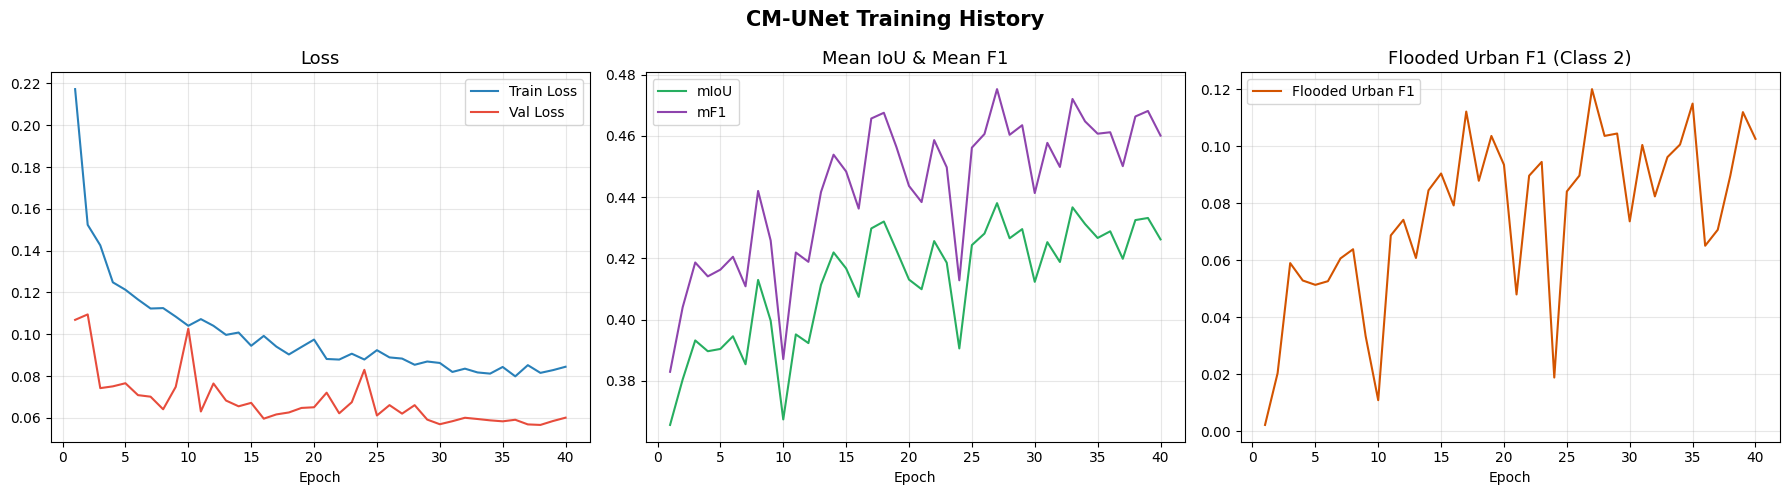

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ep = range(1, epochs + 1)

axes[0].plot(ep, history["train_loss"], label="Train Loss", color="#2980B9")
axes[0].plot(ep, history["val_loss"],   label="Val Loss",   color="#E74C3C")
axes[0].set_title("Loss", fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(ep, history["miou"], label="mIoU", color="#27AE60")
axes[1].plot(ep, history["mf1"],  label="mF1",  color="#8E44AD")
axes[1].set_title("Mean IoU & Mean F1", fontsize=13)
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(ep, history["urban_f1"], label="Flooded Urban F1", color="#D35400")
axes[2].set_title("Flooded Urban F1 (Class 2)", fontsize=13)
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle("CM-UNet Training History", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("cm_unet_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## <span style="color:#3498DB;">6. Results & Visualisation</span>

Loading the best checkpoint and visualising predictions on 4 validation samples:

- **Left**: SAR image (Band 0, grayscale)
- **Middle**: Ground truth mask (0: Non-Flooded, 1: Flooded Open, 2: Flooded Urban)
- **Right**: CM-UNet prediction

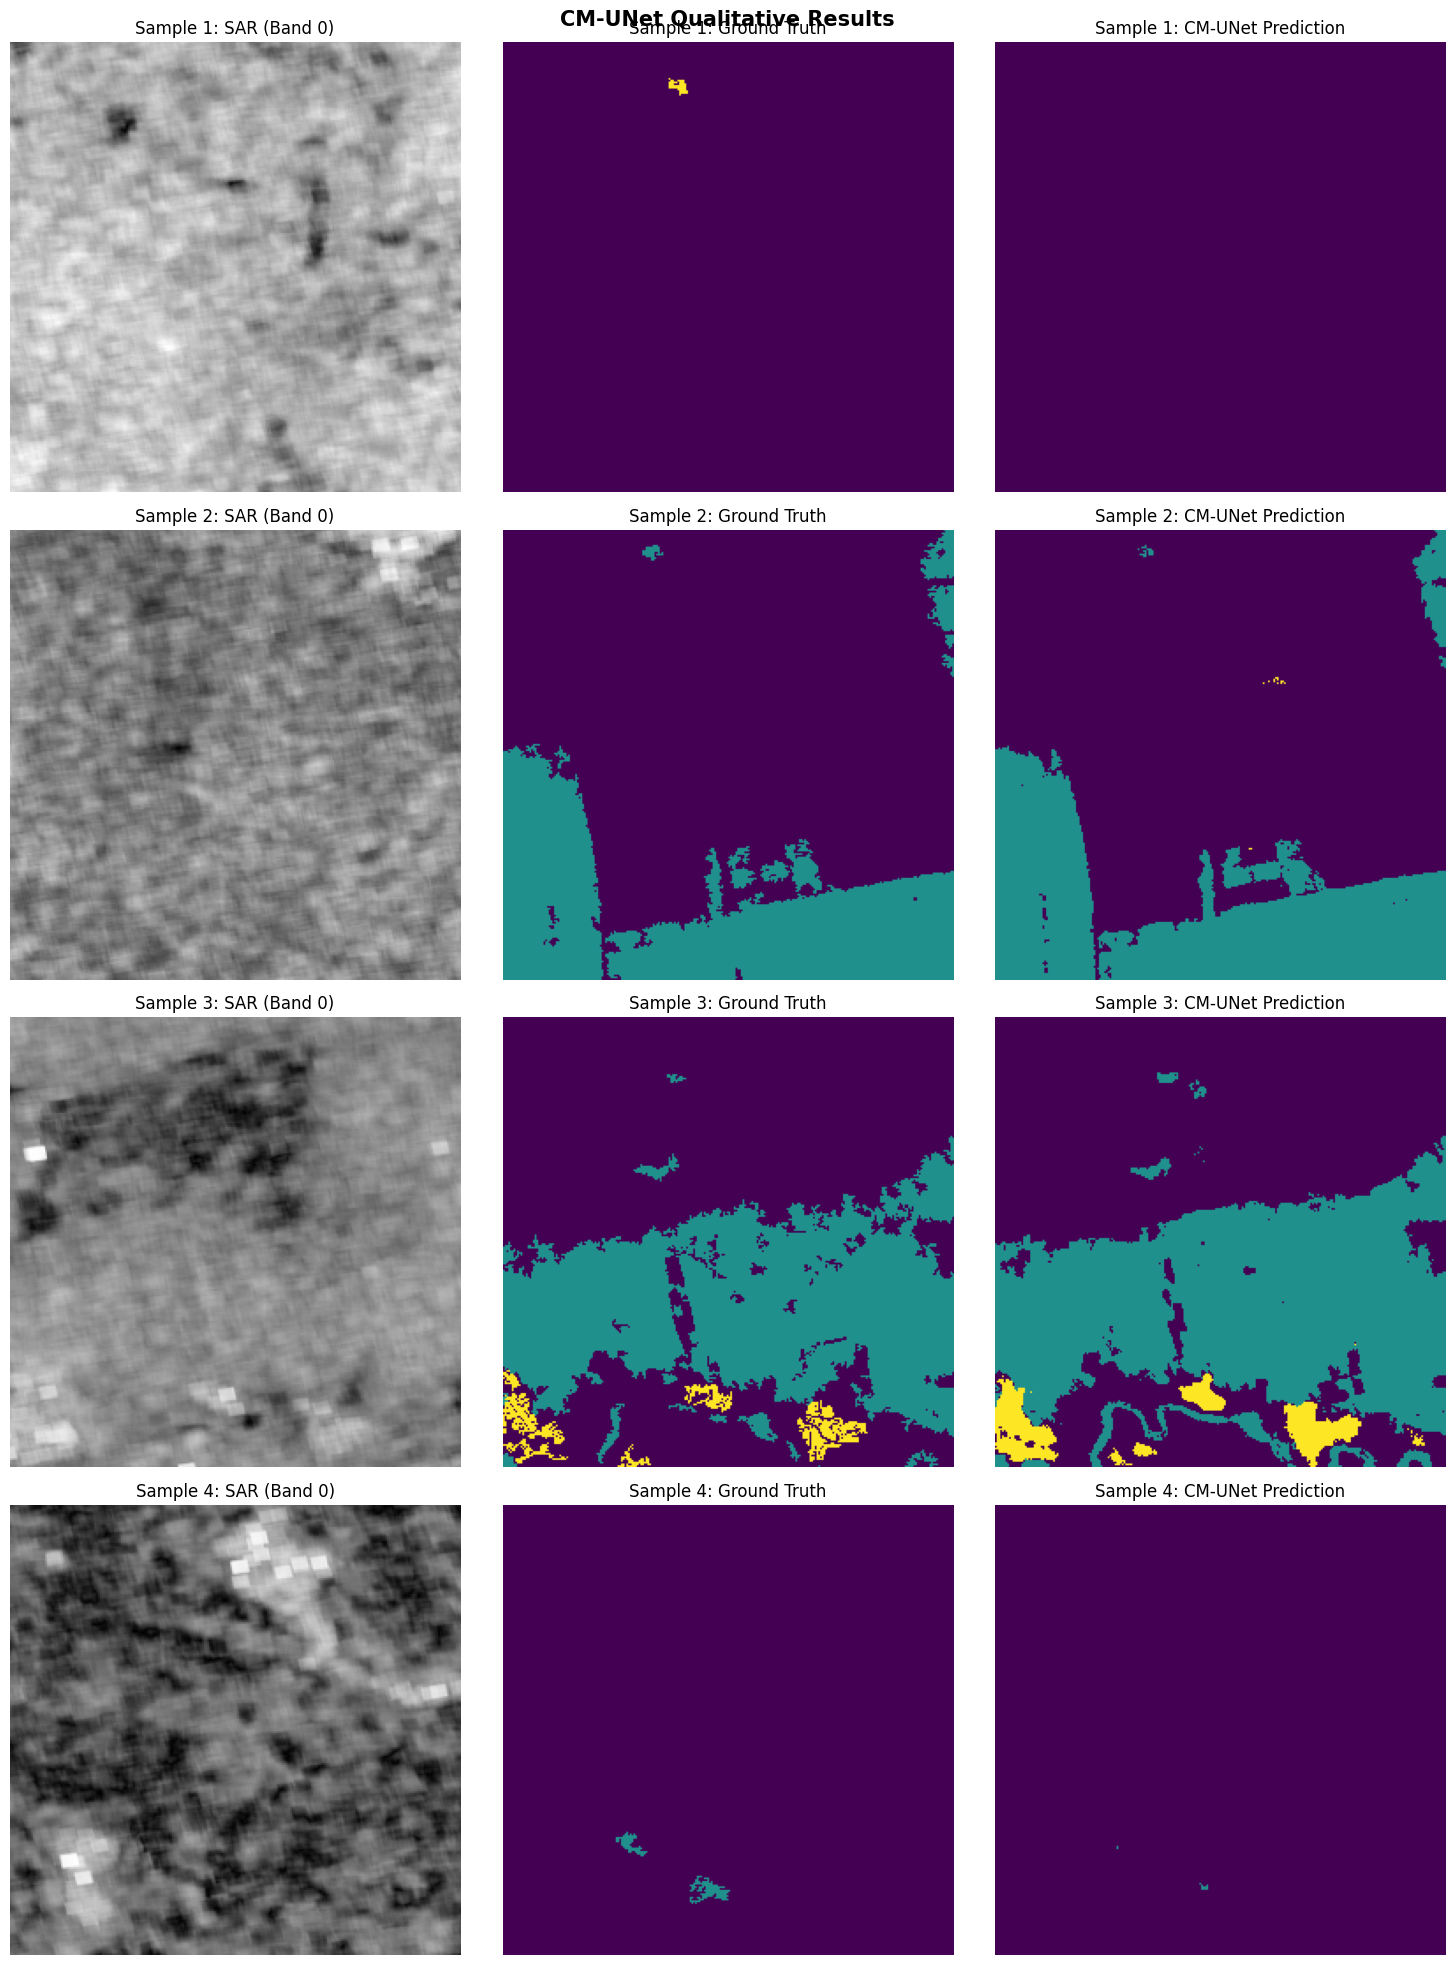

In [15]:
model.load_state_dict(torch.load("cm_unet_best.pth", map_location=device))
model.eval()

val_images, val_masks = next(iter(val_loader))
val_images = val_images.to(device)

with torch.no_grad():
    if scaler is not None:
        with torch.amp.autocast("cuda"):
            raw_preds = model(val_images)
    else:
        raw_preds = model(val_images)

pred_masks     = torch.argmax(raw_preds, dim=1).cpu().numpy()
val_images_cpu = val_images.cpu().numpy()
val_masks_cpu  = val_masks.cpu().numpy()

num_samples = min(4, batch_size)
fig, axes   = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))

for i in range(num_samples):
    axes[i, 0].imshow(val_images_cpu[i, 0], cmap="gray")
    axes[i, 0].set_title(f"Sample {i+1}: SAR (Band 0)")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(val_masks_cpu[i], cmap="viridis", vmin=0, vmax=2)
    axes[i, 1].set_title(f"Sample {i+1}: Ground Truth")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(pred_masks[i], cmap="viridis", vmin=0, vmax=2)
    axes[i, 2].set_title(f"Sample {i+1}: CM-UNet Prediction")
    axes[i, 2].axis("off")

plt.suptitle("CM-UNet Qualitative Results", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("cm_unet_predictions.png", dpi=150, bbox_inches="tight")
plt.show()